<a href="https://colab.research.google.com/github/rafaelromwno/am-t4-s1a2026/blob/main/aula-15/SVMCensus0611.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Carregamento de Dados | SVM Base [Fase 1 - census_data]

## Importar dados do Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Bibliotecas de Python

In [4]:
!pip -q install plotly
!pip -q install yellowbrick

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_census

In [6]:
import pickle

In [7]:
with open('/content/drive/MyDrive/Eu/FATEC/CICLO-V/ML/P1/census.pkl', mode = 'rb') as f:
   X_census_treinamento, Y_census_treinamento, X_census_teste, Y_census_teste = pickle.load(f)

In [8]:
X_census_treinamento.shape, Y_census_treinamento.shape

((27676, 108), (27676,))

In [9]:
X_census_teste.shape, Y_census_teste.shape

((4885, 108), (4885,))

# Pipeline SVM | SVM Base [Fase 2 - census_data]

## Treinamento do SVM

In [10]:
from sklearn.svm import SVC

In [11]:
svm_census_data = SVC(

    kernel='rbf',

    random_state=1
)

svm_census_data.fit(
    X_census_treinamento,
    Y_census_treinamento
)

SVC(random_state=1)

In [12]:
modelo = SVC(

    kernel='rbf',              # funcao de kernel (linear, poly, rbf, sigmoid)

    C=1.0,                     # penalidade por erro de classificacao (regularizacao)

    gamma='scale',             # alcance de influencia de cada amostra no kernel

    degree=3,                  # grau do polinomio (apenas para kernel='poly')

    class_weight=None,         # peso das classes (util em base desbalanceada)

    probability=False,         # habilita estimativa de probabilidade

    random_state=1             # garante reproducibilidade dos resultados
)

# Pipeline Medicoes Harmonicas | SVM Base [Fase 3 - census_data]

## Avaliacao do SVM

In [13]:
previsoes_svm = svm_census_data.predict(X_census_teste)

In [14]:
previsoes_svm

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [15]:
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [17]:
accuracy_score(Y_census_teste, previsoes_svm)

0.8493346980552713

In [18]:
from yellowbrick.classifier import ConfusionMatrix

In [19]:
print(classification_report(Y_census_teste, previsoes_svm))

              precision    recall  f1-score   support

       <=50K       0.87      0.94      0.90      3693
        >50K       0.75      0.57      0.65      1192

    accuracy                           0.85      4885
   macro avg       0.81      0.75      0.78      4885
weighted avg       0.84      0.85      0.84      4885



0.8493346980552713

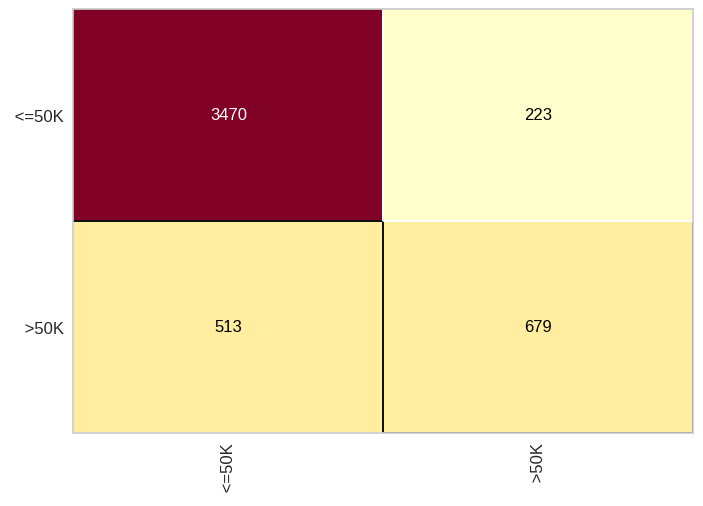

In [20]:
cm_census_svm = ConfusionMatrix(svm_census_data)
cm_census_svm.fit(X_census_treinamento, Y_census_treinamento)
cm_census_svm.score(X_census_teste, Y_census_teste)